# AmericanStories — Data Overview, Descriptions & Samples

The [`dell-research-harvard/AmericanStories`](https://huggingface.co/datasets/dell-research-harvard/AmericanStories)
dataset: article-level OCR of historical U.S. newspapers (Library of Congress *Chronicling America*).

This notebook (1) loads the data, (2) describes its structure and coverage over time / geography /
newspapers, and (3) shows representative article samples.

**Loading gotchas (already handled below):**
- `datasets==2.14.5` needs `fsspec<=2023.9.2`; newer `fsspec` makes `load_dataset` raise
  `NotImplementedError: Loading a dataset cached in a LocalFileSystem is not supported`.
- The dataset's `main` branch (loader v0.2.0, changed 2025-03-26) is **broken** and returns 0 rows for
  almost all years. We pin `revision="e26b7f7f48c6"` (v0.1.0), the complete build already cached locally.

In [1]:
import os, json, random, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

%matplotlib inline
pd.set_option("display.max_columns", None)

DATA_DIR  = "/kellogg/proj/dashun/ruipan/fame/data"
CACHE_DIR = os.path.join(DATA_DIR, "raw_historical_newspaper")
PROC_DIR  = os.path.join(DATA_DIR, "processed")
META_CSV  = os.path.join(DATA_DIR, "newspaper_meta", "newspaper_metainfo.csv")

## 1. Load the dataset

In [2]:
import fsspec
# Guard: stale/newer fsspec is the #1 cause of the LocalFileSystem error above.
if fsspec.__version__ > "2023.9.2":
    raise RuntimeError(
        f"fsspec is {fsspec.__version__}. Need <= 2023.9.2 for datasets 2.14.5.\n"
        "Fix:  pip install 'fsspec[http]==2023.9.2'  then RESTART THE KERNEL."
    )
print("fsspec:", fsspec.__version__, "(ok)")

dataset = load_dataset(
    "dell-research-harvard/AmericanStories",
    "all_years",
    cache_dir=CACHE_DIR,
    revision="e26b7f7f48c6",   # v0.1.0 build; main/v0.2.0 returns 0 rows
)
print(f"Loaded {len(dataset)} yearly splits")

fsspec: 2023.9.2 (ok)


Loaded 167 yearly splits


## 2. Dataset structure

Each yearly split is an Arrow-backed table; one row = one article with these fields.

In [3]:
years = sorted(int(y) for y in dataset.keys())
features = dataset[str(years[0])].features

print(f"Year splits : {len(years)}  ({min(years)}-{max(years)})")
print("\nFields per article:")
for name, feat in features.items():
    print(f"  - {name:15s} {feat.dtype}")

total = sum(dataset[str(y)].num_rows for y in years)
print(f"\nTotal articles: {total:,}")

Year splits : 167  (1774-1963)

Fields per article:
  - article_id      string
  - newspaper_name  string
  - edition         string
  - date            string
  - page            string
  - headline        string
  - byline          string
  - article         string

Total articles: 77,887,521


## 3. Articles per year

Summary of yearly article counts:


count          167
mean       466,392
std        594,849
min             12
25%          9,318
50%        254,946
75%        622,113
max      2,405,974
Name: n_articles, dtype: object


Top 10 years by article volume:


,year,n_articles
0,1922,"2,405,974"
1,1921,"2,334,112"
2,1920,"2,041,192"
3,1919,"1,981,192"
4,1914,"1,931,901"
5,1909,"1,926,228"
6,1918,"1,920,102"
7,1915,"1,878,654"
8,1908,"1,842,874"
9,1916,"1,838,797"


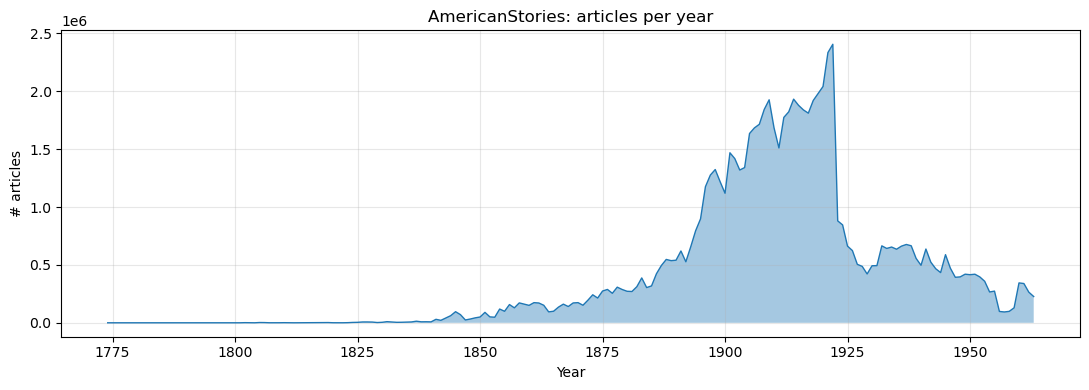

In [4]:
counts = pd.DataFrame(
    [(y, dataset[str(y)].num_rows) for y in years],
    columns=["year", "n_articles"],
)

print("Summary of yearly article counts:")
display(counts["n_articles"].describe().apply(lambda v: f"{v:,.0f}"))

top = counts.sort_values("n_articles", ascending=False).head(10).reset_index(drop=True)
print("\nTop 10 years by article volume:")
display(top.assign(n_articles=top["n_articles"].map("{:,}".format)))

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(counts["year"], counts["n_articles"], alpha=0.4)
ax.plot(counts["year"], counts["n_articles"], lw=1)
ax.set(title="AmericanStories: articles per year", xlabel="Year", ylabel="# articles")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Geographic coverage (by state)

Uses the precomputed `dict_year_state_articles.json` (article counts mapped to states via
`newspaper_metainfo.csv`). Coverage spans the years for which the mapping was built (1850-1959) and is
approximate — only newspaper titles that matched the metadata file are attributed to a state.

States represented: 49  |  years covered: 110


,state,n_articles
0,District of Columbia,"15,372,501"
1,Connecticut,"8,265,884"
2,California,"5,968,372"
3,Arizona,"5,922,835"
4,Colorado,"5,192,878"
5,New York,"4,670,999"
6,Alaska,"4,413,491"
7,Alabama,"4,257,581"
8,Arkansas,"3,949,057"
9,Delaware,"2,612,954"


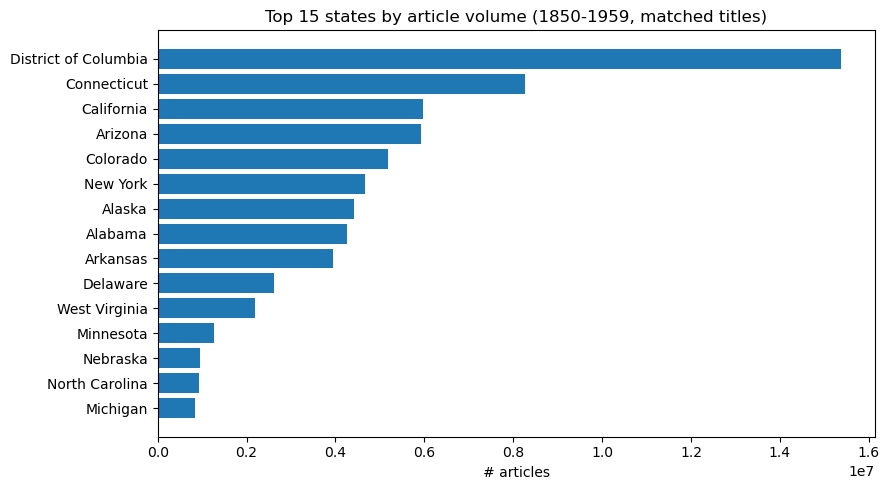

In [5]:
with open(os.path.join(PROC_DIR, "dict_year_state_articles.json")) as f:
    year_state = json.load(f)

state_tot = {}
for y, d in year_state.items():
    for st, c in d.items():
        state_tot[st] = state_tot.get(st, 0) + c

state_df = (pd.Series(state_tot, name="n_articles")
              .sort_values(ascending=False)
              .rename_axis("state").reset_index())
print(f"States represented: {len(state_df)}  |  years covered: {len(year_state)}")
display(state_df.head(15).assign(n_articles=lambda d: d["n_articles"].map("{:,}".format)))

fig, ax = plt.subplots(figsize=(9, 5))
top15 = state_df.head(15).iloc[::-1]
ax.barh(top15["state"], top15["n_articles"])
ax.set(title="Top 15 states by article volume (1850-1959, matched titles)", xlabel="# articles")
plt.tight_layout(); plt.show()

## 5. Top newspapers

In [6]:
with open(os.path.join(PROC_DIR, "dict_year_newspaper_articles.json")) as f:
    year_paper = json.load(f)

paper_tot = {}
for y, d in year_paper.items():
    for name, c in d.items():
        paper_tot[name] = paper_tot.get(name, 0) + c

paper_df = (pd.Series(paper_tot, name="n_articles")
              .sort_values(ascending=False)
              .rename_axis("newspaper").reset_index())
print(f"Distinct newspapers (1850-1959): {len(paper_df):,}")
display(paper_df.head(20).assign(n_articles=lambda d: d["n_articles"].map("{:,}".format)))

Distinct newspapers (1850-1959): 1,660


,newspaper,n_articles
0,Evening star.,"9,913,885"
1,New-York tribune.,"3,093,960"
2,The Washington times.,"2,691,163"
3,The Birmingham age-herald.,"2,682,450"
4,Evening journal.,"2,150,118"
5,Arizona republican.,"1,839,233"
6,The Waterbury Democrat.,"1,499,938"
7,Imperial Valley press.,"1,498,264"
8,The Washington herald.,"1,479,789"
9,The San Francisco call.,"1,409,830"


## 6. Article field statistics (on a random sample)

Computed on a random sample of articles from a few representative years (full corpus is ~78M articles),
to characterize article length and how often optional fields (headline, byline) are populated.

Sampled 16,000 articles from years [1860, 1900, 1925, 1940]

Article length (words):


count    16000.0
mean       144.6
std        185.0
min          1.0
25%         33.0
50%         75.0
75%        176.0
max       1700.0
Name: n_words, dtype: float64


By year:


,median_words,mean_words,pct_with_headline,pct_with_byline
year,,,,
1860,82.0,166.0,0.506,0.020
1900,68.5,142.0,0.607,0.022
1925,73.0,134.0,0.637,0.078
1940,78.0,136.0,0.651,0.136


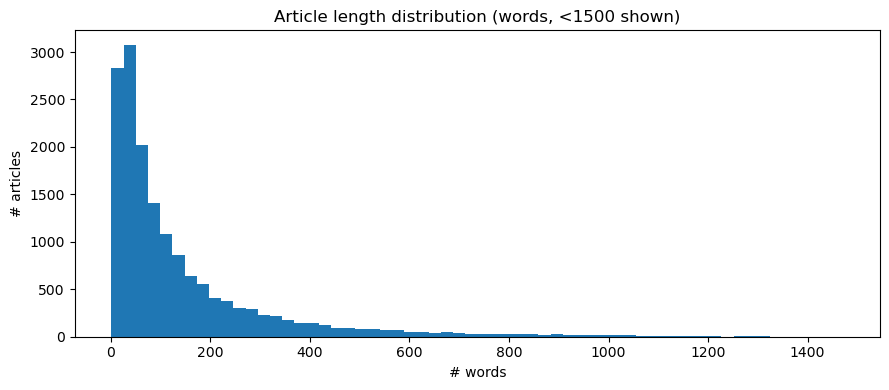

In [7]:
rng = random.Random(0)
sample_years = [1860, 1900, 1925, 1940]
rows = []
for y in sample_years:
    n = dataset[str(y)].num_rows
    idx = sorted(rng.sample(range(n), min(n, 4000)))
    batch = dataset[str(y)][idx]            # single batched query -> dict of columns
    for art, hl, by in zip(batch["article"], batch["headline"], batch["byline"]):
        rows.append({
            "year": y,
            "n_chars": len(art),
            "n_words": len(art.split()),
            "has_headline": bool(hl.strip()),
            "has_byline": bool(by.strip()),
        })
samp = pd.DataFrame(rows)

print(f"Sampled {len(samp):,} articles from years {sample_years}\n")
print("Article length (words):")
display(samp["n_words"].describe().round(1))

summary = samp.groupby("year").agg(
    median_words=("n_words", "median"),
    mean_words=("n_words", "mean"),
    pct_with_headline=("has_headline", "mean"),
    pct_with_byline=("has_byline", "mean"),
).round({"mean_words": 0, "pct_with_headline": 3, "pct_with_byline": 3})
print("\nBy year:")
display(summary)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(samp.loc[samp["n_words"] < 1500, "n_words"], bins=60)
ax.set(title="Article length distribution (words, <1500 shown)", xlabel="# words", ylabel="# articles")
plt.tight_layout(); plt.show()

## 7. Sample articles

In [8]:
def show_random_articles(k=4, seed=42, maxchars=1400):
    r = random.Random(seed)
    for _ in range(k):
        y = r.choice(years)
        i = r.randrange(dataset[str(y)].num_rows)
        a = dataset[str(y)][i]
        print("=" * 88)
        print(f"{a['newspaper_name']}  |  {a['date']}  |  page {a['page']}   "
              f"(split {y}, idx {i}, id {a['article_id']})")
        if a["headline"].strip():
            print("HEADLINE:", a["headline"].strip())
        if a["byline"].strip():
            print("BYLINE  :", a["byline"].strip())
        print("-" * 88)
        body = a["article"].strip()
        print(textwrap.fill(body[:maxchars], width=88) + ("..." if len(body) > maxchars else ""))
        print()

show_random_articles(4)

Evening star.  |  1960-10-18  |  page p27   (split 1960, idx 58369, id 3_1960-10-18_p27_sn83045462_00280608063_1960101801_0365)
HEADLINE: HUNTING


and
FISHING
BYLINE  : Those who KNOW him. viii \,
----------------------------------------------------------------------------------------
Those who know him, will hail the choice Of Robert q. Martin as new chief Of the
Virginia Game Commissions Fish Divi- sion.   Martin, assistant chief for more than five
years, succeeds the late Gay w. Butler, who died In September.   The new chief may be
ex- pected to carry on the policies Of his predecessor, who had served 30 years in his
post and designed and put into service four large hatcheries and one trout rearing
station.   At the same time, Martin is young, capable and aggressive, and has the best
interests Of the fishermen at heart. One Of the things ny fishermen can hope for are
more streams set aside strictly for their sport.   -   Before offshore angling fell on
for the season ct Ocean City.

---
### Notes
- Re-run with a different `seed` in `show_random_articles` to see other articles.
- For name/keyword searches across the corpus, see `get_american_newspaper.ipynb`
  (`get_name_article`) — substring matching over each year's `article` text.

## 8. Keyword search — example: "federal government"

Vectorized, case-insensitive substring search over a year's `article` column (PyArrow
`match_substring` — far faster than looping row-by-row). `search_phrase` returns the matching
row indices; `show_matches` prints examples with the phrase in context.

In [9]:
import re
import pyarrow.compute as pc

def search_phrase(phrase, year, ignore_case=True):
    """Indices of articles in `year` whose text contains `phrase` (vectorized)."""
    col = dataset[str(year)].data.column("article")
    mask = pc.match_substring(col, phrase, ignore_case=ignore_case)
    return pc.indices_nonzero(mask).to_pylist()

def _context(text, phrase, width=300):
    m = re.search(re.escape(phrase), text, re.IGNORECASE)
    if not m:
        return re.sub(r"\s+", " ", text[:2 * width]).strip()
    s, e = max(0, m.start() - width), min(len(text), m.end() + width)
    snip = ("..." if s else "") + text[s:e] + ("..." if e < len(text) else "")
    return re.sub(r"\s+", " ", snip).strip()

def show_matches(phrase, year, n=6, width=300):
    idx = search_phrase(phrase, year)
    print(f"Year {year}: {len(idx):,} of {dataset[str(year)].num_rows:,} "
          f"articles mention '{phrase}'\n")
    for k, i in enumerate(idx[:n], 1):
        a = dataset[str(year)][i]
        print("=" * 90)
        print(f"[{k}] {a['newspaper_name']}  |  {a['date']}  |  page {a['page']}  (idx {i})")
        if a["headline"].strip():
            print("    headline:", re.sub(r"\s+", " ", a["headline"]).strip()[:90])
        print("-" * 90)
        print(textwrap.fill(_context(a["article"], phrase, width), 90))
        print()
    return idx

In [10]:
# Retrieve & show articles mentioning "federal government" in 1900
fed_idx = show_matches("federal government", 1900, n=6)
# `fed_idx` holds all matching row indices for that year, e.g. len(fed_idx) total matches.

Year 1900: 516 of 1,118,970 articles mention 'federal government'

[1] Evening star.  |  1900-03-23  |  page p6  (idx 4)
------------------------------------------------------------------------------------------
...ious forms of labor-employing enter prises which will comport with the dignity of the
capital and at the same time swell the self-supporting population. 1t is excep- tionally
situated to attract workers and in vestors as regards the financial burdens placed upon
the people. The aid furnished by the federal government in maintaining the municipal
machinery, the extensive i'm provements made possible by this division of the cost, the
growing prestige of the city as a desirable place of residence and well-governed
community, all tend to spread its fame and invite home-makers, artisans and capitalists.
The propos...

[2] The Van Buren press.  |  1900-05-12  |  page p4  (idx 142)
    headline: uCHEH(DR MOVEMENT. Report Of Chairman Gardener OF the Committee on Labor to the House. 